In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
a = 20.0    # mm
b = 10.0    # mm
D = 84.0    # mm^2/s
dx = dy = 0.1
nx = int(a/dx) + 1
ny = int(b/dy) + 1
x = np.linspace(0, a, nx)
y = np.linspace(0, b, ny)
X, Y = np.meshgrid(x, y)

In [17]:
#Solución analitica
def analytic_solution(X, Y, a=20, b=10):
    return (100* np.sin(3*np.pi*X/a)* np.sinh(3*np.pi*Y/a)/ np.sinh(3*np.pi*b/a))
T_exact = analytic_solution(X, Y, a, b)

In [7]:
def static_FDM(T_ini, tol=1e-6, max_iter=100000):
    T = T_ini.copy()
    T_new = T.copy()
    for n in range(max_iter):
        T_new[1:-1, 1:-1] = 0.25 * (T[2:, 1:-1] + T[:-2, 1:-1] + T[1:-1, 2:]+ T[1:-1, :-2])
        error = np.max(np.abs(T_new - T))
        T, T_new = T_new, T
        if error < tol:
            break
    return T, n+1, error

In [15]:
T0 = np.zeros((ny, nx))
T0[-1, :] = 100*np.sin(3*np.pi*x/a)
T_static, niter, error = static_FDM(T0)

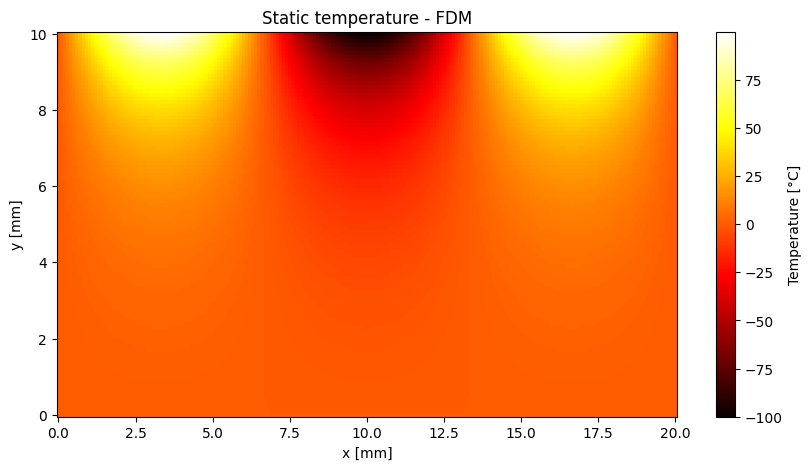

In [14]:
plt.figure(figsize=(10,5))
plt.pcolormesh(
    X, Y, T_static,
    shading="auto",
    cmap="hot")
plt.colorbar(label="Temperature [°C]")
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title("Static temperature - FDM")
plt.show()

In [18]:
error_matrix = np.abs(T_static - T_exact)
print(
    "Maximum error:",
    np.max(error_matrix[1:-1, 1:-1])
)

Maximum error: 0.006041221752454362


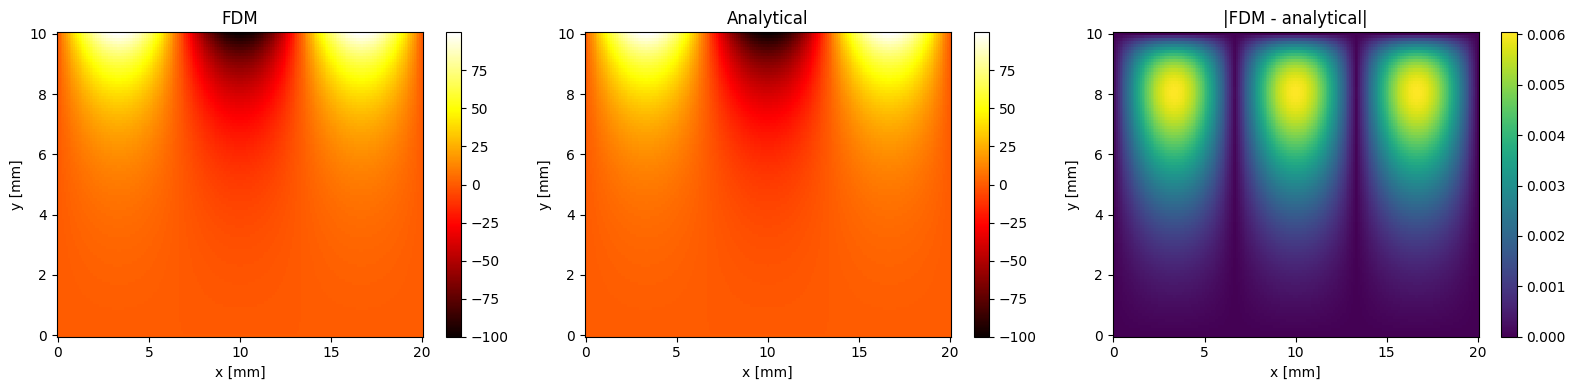

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
p0 = ax[0].pcolormesh(
    X, Y, T_static,
    shading="auto",
    cmap="hot")
ax[0].set_title("FDM")
plt.colorbar(p0, ax=ax[0])
p1 = ax[1].pcolormesh(
    X, Y, T_exact,
    shading="auto",
    cmap="hot"
)
ax[1].set_title("Analytical")
plt.colorbar(p1, ax=ax[1])
p2 = ax[2].pcolormesh(
    X, Y,
    np.abs(T_static-T_exact),
    shading="auto"
)
ax[2].set_title("|FDM - analytical|")
plt.colorbar(p2, ax=ax[2])
for axis in ax:
    axis.set_xlabel("x [mm]")
    axis.set_ylabel("y [mm]")
plt.tight_layout()
plt.show()

In [26]:
#Punto 3
dt_max = (dx**2 * dy**2/(2*D*(dx**2 + dy**2)))
dt = 0.9*dt_max
print(dt)

2.678571428571429e-05


In [27]:
def do_timestep(T):
    T_new = T.copy()
    T_new[1:-1,1:-1] = (
        T[1:-1,1:-1]+
        D*dt*(
            (T[1:-1,2:] - 2*T[1:-1,1:-1] + T[1:-1,:-2])/dx**2
            +
            (T[2:,1:-1] - 2*T[1:-1,1:-1] + T[:-2,1:-1])/dy**2))
    # Condiciones de frontera
    T_new[0,:] = 0
    T_new[:,0] = 0
    T_new[:,-1] = 0
    T_new[-1,:] = (
        100*np.sin(3*np.pi*x/a))
    return T_new

In [28]:
t_final = 1.0
nsteps = int(t_final/dt)
for n in range(nsteps):
    T = do_timestep(T0)

In [30]:
#Para varios tiempos
times = [0.01, 0.05, 0.2, 0.5, 1.0]
T = np.zeros((ny,nx))
T[-1,:] = 100*np.sin(3*np.pi*x/a)
snapshots = {}
current_time = 0
for n in range(int(max(times)/dt)+1):
    T = do_timestep(T)
    current_time += dt
    for target in times:
        if (target not in snapshots and current_time >= target):
            snapshots[target] = T.copy()

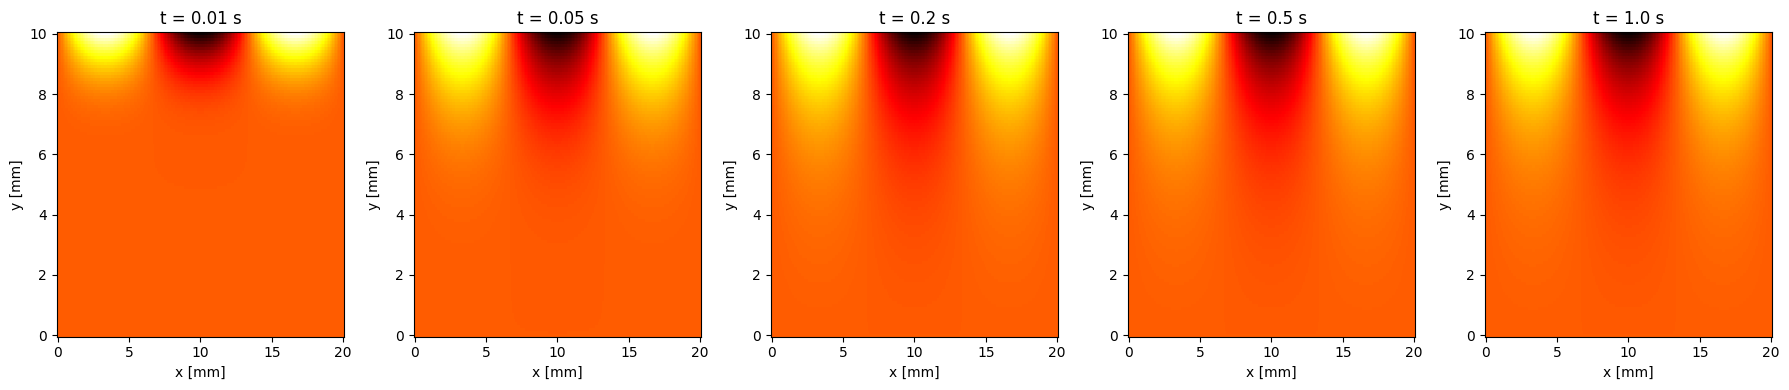

In [31]:
fig, ax = plt.subplots(
    1,
    len(times),
    figsize=(18,4))
for axis, time in zip(ax, times):
    im = axis.pcolormesh(
        X,
        Y,
        snapshots[time],
        shading="auto",
        cmap="hot"
    )
    axis.set_title(f"t = {time} s")
    axis.set_xlabel("x [mm]")
    axis.set_ylabel("y [mm]")

plt.tight_layout()
plt.show()